<a href="https://colab.research.google.com/github/GyanAnargya/Kumpulan-Hasil-Tugas/blob/main/24_Dashboard_Data_RevinaAgnanta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-21-d71efccb3e6a>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='produk', x='profit', data=avg_profit, palette='coolwarm', ax=axs[0, 1])
<ipython-input-21-d71efccb3e6a>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='kepuasan_pelanggan', data=df, palette='pastel', ax=axs[1, 1])


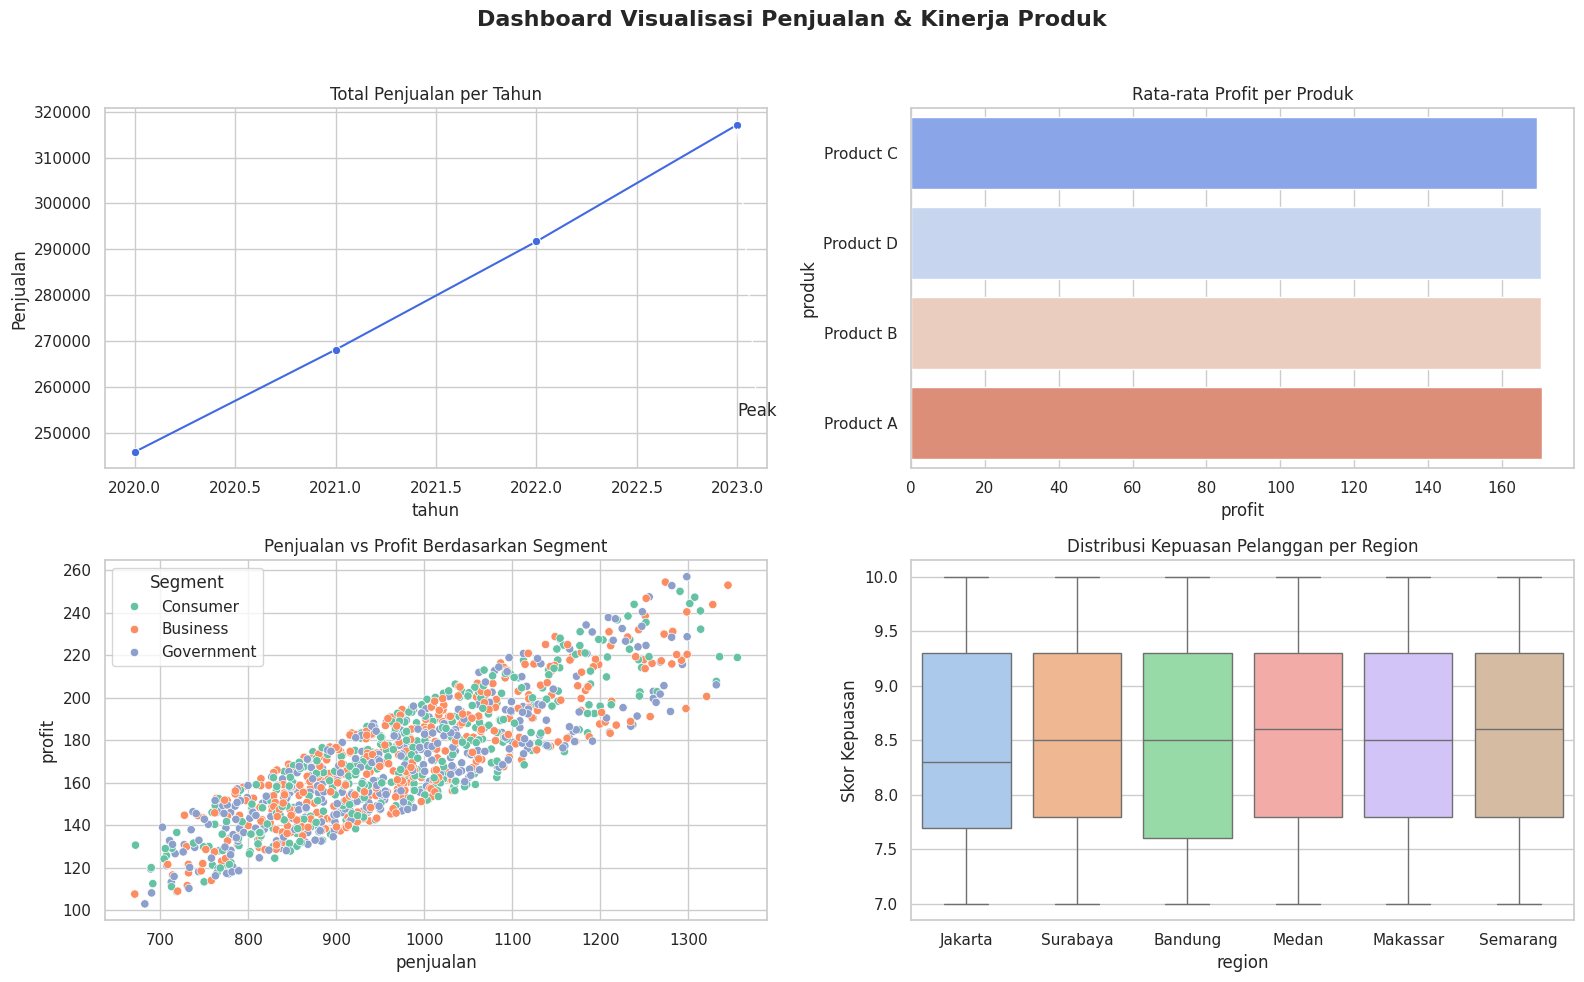

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Data modul 8/dashboard_data.csv')

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dashboard Visualisasi Penjualan & Kinerja Produk", fontsize=16, fontweight='bold')

sales_per_year = df.groupby('tahun')['penjualan'].sum().reset_index()
sns.lineplot(x='tahun', y='penjualan', data=sales_per_year, marker='o', ax=axs[0, 0], color='royalblue')
axs[0, 0].set_title('Total Penjualan per Tahun')
axs[0, 0].set_ylabel('Penjualan')
axs[0, 0].annotate('Peak',
                   xy=(sales_per_year['tahun'].iloc[-1], sales_per_year['penjualan'].iloc[-1]),
                   xytext=(sales_per_year['tahun'].iloc[-1], sales_per_year['penjualan'].max()*0.8),
                   arrowprops=dict(facecolor='black', arrowstyle='->'))

avg_profit = df.groupby('produk')['profit'].mean().sort_values().reset_index()
sns.barplot(y='produk', x='profit', data=avg_profit, palette='coolwarm', ax=axs[0, 1])
axs[0, 1].set_title('Rata-rata Profit per Produk')

sns.scatterplot(x='penjualan', y='profit', hue='segment', data=df, ax=axs[1, 0], palette='Set2')
axs[1, 0].set_title('Penjualan vs Profit Berdasarkan Segment')
axs[1, 0].legend(title='Segment')

sns.boxplot(x='region', y='kepuasan_pelanggan', data=df, palette='pastel', ax=axs[1, 1])
axs[1, 1].set_title('Distribusi Kepuasan Pelanggan per Region')
axs[1, 1].set_ylabel('Skor Kepuasan')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dashboard_visualisasi.png")
plt.savefig("dashboard_visualisasi.pdf")
plt.show()